# Klasifikasi Kesegaran Buah Menggunakan Metode GLCM dan Random Forest
## Percobaan 2 — Preprocessing: Resize + Median Filter + Histogram Equalization (3 Preprocessing)
### Nama Anggota
- Thoriq Abdillah Falian Kusuma : F1D02410098
- Jasmine Aulia Santoso : F1D02410010
- Ulul Asmi : F1D02410144
- Fatriya Annastha Putra : F1D02410046

## Import Library

Cell dibawah mengimpor seluruh library yang dibutuhkan sepanjang program.

Library `os` digunakan untuk melakukan navigasi sistem file, sehingga program dapat membaca folder dataset dan melakukan iterasi secara otomatis pada setiap subfolder kelas. `OpenCV (cv2)` digunakan untuk membaca citra dari media penyimpanan, melakukan konversi warna dari BGR ke grayscale, serta mengubah ukuran citra (resize) agar memiliki dimensi yang seragam. Untuk keperluan visualisasi, `Matplotlib (matplotlib.pyplot)` digunakan untuk menampilkan sampel citra, grafik distribusi data, dan confusion matrix.

Dalam pengolahan data numerik, `NumPy` digunakan untuk melakukan operasi pada array multidimensi yang berfungsi menyimpan data citra, label, serta hasil perhitungan fitur. `Pandas` digunakan untuk mengelola data hasil ekstraksi fitur dalam bentuk DataFrame serta menyimpan dan membaca data dalam format CSV. Pembagian dataset menjadi data latih dan data uji dilakukan menggunakan fungsi `train_test_split` dari library `scikit-learn`, sehingga proses pembagian data dapat dilakukan secara acak namun tetap dapat direproduksi.

Pada tahap ekstraksi fitur tekstur, digunakan fungsi `graycomatrix` dan `graycoprops` dari library `scikit-image` untuk membentuk Gray-Level Co-occurrence Matrix (GLCM) dan menghitung berbagai karakteristik tekstur seperti contrast, correlation, energy, dan homogeneity. Selain itu, fungsi `entrop` dari library `SciPy` digunakan untuk menghitung nilai entropi berdasarkan distribusi probabilitas pada matriks GLCM sebagai fitur tambahan yang merepresentasikan kompleksitas tekstur citra.

Tahap klasifikasi dilakukan menggunakan tiga algoritma pembelajaran mesin dari library scikit-learn, yaitu RandomForestClassifier sebagai metode klasifikasi berbasis ensemble pohon keputusan, SVC (Support Vector Classifier) sebagai implementasi algoritma Support Vector Machine (SVM) dengan kernel Radial Basis Function (RBF), serta KNeighborsClassifier yang menerapkan metode K-Nearest Neighbors (KNN). Evaluasi performa model dilakukan menggunakan berbagai metrik dari sklearn.metrics, meliputi accuracy, precision, recall, F1-score, classification report, dan confusion matrix. Selanjutnya, Seaborn digunakan untuk menghasilkan visualisasi statistik tingkat lanjut, khususnya dalam menampilkan heatmap correlation matrix yang digunakan untuk menganalisis hubungan antar fitur yang diekstraksi.

In [1]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns

## Data Loading

Cell ini bertugas membaca seluruh gambar dari folder dataset dan melakukan resize seragam ke ukuran 250×250 piksel.

Yang dilakukan:


Fungsi resize_image(image, target_size=(250, 250)) didefinisikan secara eksplisit sebagai wrapper cv.resize() dan lebih modular dibanding Percobaan 1
Iterasi setiap subfolder dalam direktori Dataset/ masing-masing subfolder mewakili satu kelas label.
Setiap gambar dibaca menggunakan cv.imread(), di-resize ke 250×250 piksel, dan dikonversi ke np.uint8.
Gambar, label kelas, dan nama file disimpan ke list terpisah, lalu dikonversi ke numpy array.


Ukuran resize: 250×250 piksel — alasan identik dengan Percobaan 1: memastikan dimensi seragam, menjaga detail tekstur permukaan apel yang relevan untuk GLCM, dan efisiensi komputasi.

In [2]:
def resize_image(image, target_size=(250, 250)):
    return cv.resize(image, target_size)

data = []
labels = []
file_name = []

dataset_path = 'Dataset'

for sub_folder in sorted(os.listdir(dataset_path)):
    folder_path = os.path.join(dataset_path, sub_folder)
    if not os.path.isdir(folder_path):
        continue
    for filename in os.listdir(folder_path):
        img_path = os.path.join(folder_path, filename)
        img = cv.imread(img_path)
        if img is None:
            continue
        img = resize_image(img, (250, 250))
        img = img.astype(np.uint8)
        data.append(img)
        labels.append(sub_folder)
        file_name.append(filename)

data = np.array(data)
labels = np.array(labels)
print(f'Total data: {len(data)}')
print(f'Labels: {np.unique(labels)}')

Total data: 828
Labels: ['Fresh_Apple' 'Moderately_Fresh_Apple' 'Rotten_Apple']


## Data Understanding

Cell ini menampilkan distribusi jumlah gambar per kelas menggunakan bar chart, bertujuan untuk memahami keseimbangan dataset sebelum proses preprocessing dan modeling.

Karakteristik Dataset:

Fresh_Apple (Apel Segar) berjumlah 507 gambar dengan proporsi ±61.2. 
Moderately_Fresh_Apple (Apel Cukup Segar) berjumlah 166 gambar dengan proporsi ±20.0.
Rotten_Apple (Apel Busuk) berjumlah 155 gambar dengan proporsi ±18.7.
Sehingga total gambar 828 dengan proporsi 100%.

Dataset yang digunakan pada Percobaan 2 identik dengan Percobaan 1, perbedaan hanya terletak pada pipeline preprocessing yang diterapkan. Distribusi tidak seimbang (imbalanced) dengan Fresh_Apple mendominasi (~3× lebih banyak dari kelas lainnya) tetap menjadi karakteristik yang perlu diperhatikan dalam interpretasi hasil evaluasi.

Karakteristik visual gambar:


Gambar diambil dengan kamera smartphone dalam kondisi pencahayaan yang bervariasi (dalam dan luar ruangan)
Background tidak seragam (meja, kain, genggaman tangan)
Apel segar: permukaan mulus, warna cerah, tekstur seragam
Apel cukup segar: mulai ada bercak, sedikit perubahan warna dan tekstur
Apel busuk: permukaan tidak merata, bercak coklat/hitam signifikan, tekstur kasar

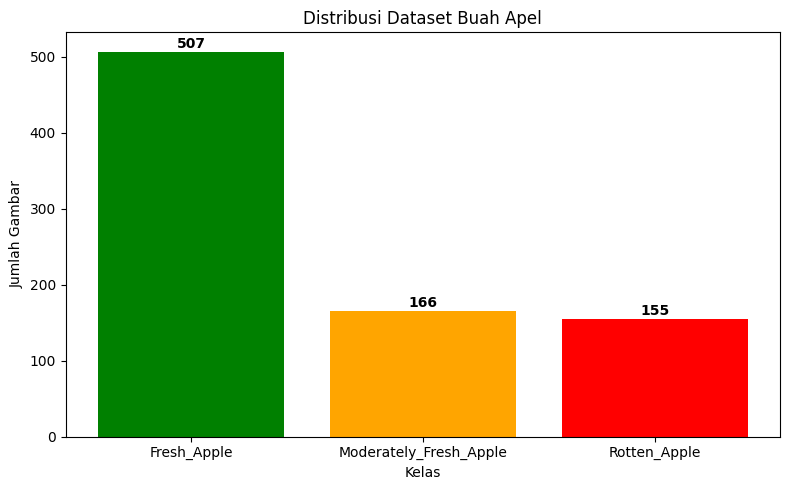

In [3]:
unique, counts = np.unique(labels, return_counts=True)
plt.figure(figsize=(8, 5))
plt.bar(unique, counts, color=['green', 'orange', 'red'])
plt.xlabel('Kelas')
plt.ylabel('Jumlah Gambar')
plt.title('Distribusi Dataset Buah Apel')
for i, (u, c) in enumerate(zip(unique, counts)):
    plt.text(i, c + 5, str(c), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# Sample Data

Cell ini menggunakan fungsi show_sample_images() untuk menampilkan contoh gambar dari setiap kelas dalam format grid.

Yang dilakukan:


Fungsi menerima array gambar, label, nama kelas, judul, dan jumlah sampel per kelas (n=3)
Menampilkan grid 3 baris × 3 kolom = 9 gambar total
Gambar BGR dikonversi ke RGB sebelum ditampilkan agar warna tampak natural
Gambar grayscale ditampilkan dengan cmap='gray'
Axis dinonaktifkan, setiap gambar diberi label nama kelasnya


Tujuan: Memverifikasi secara visual bahwa gambar terbaca dengan benar dan label sesuai konten. Fungsi ini bersifat reusable dipanggil kembali setelah setiap tahap preprocessing (Grayscale, Median Filter, Histogram Equalization) untuk memvisualisasikan perubahan yang terjadi.

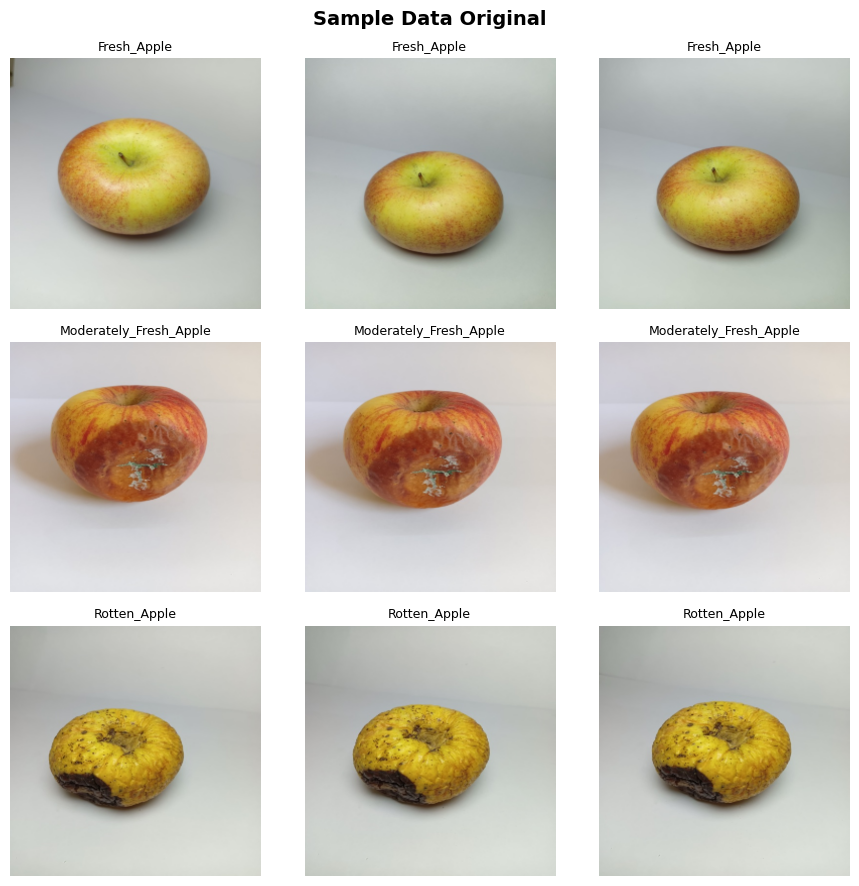

In [4]:
def show_sample_images(images, labels, class_names, title='Sample Images', n=3):
    fig, axes = plt.subplots(len(class_names), n, figsize=(n*3, len(class_names)*3))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    for i, cls in enumerate(class_names):
        idx = np.where(labels == cls)[0]
        for j in range(min(n, len(idx))):
            img = images[idx[j]]
            if len(img.shape) == 3:
                axes[i][j].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
            else:
                axes[i][j].imshow(img, cmap='gray')
            axes[i][j].set_title(f'{cls}', fontsize=9)
            axes[i][j].axis('off')
    plt.tight_layout()
    plt.show()

class_names = sorted(np.unique(labels))
show_sample_images(data, labels, class_names, 'Sample Data Original')

## Grayscale

Cell ini mengkonversi seluruh gambar dari format BGR (3-channel) ke Grayscale (1-channel) menggunakan cv.cvtColor(img, cv.COLOR_BGR2GRAY).

Yang dilakukan:


Iterasi setiap gambar dalam array data
Setiap gambar dikonversi ke grayscale dan ditambahkan ke list img_grey
Hasil disimpan sebagai numpy array dan divisualisasikan dengan show_sample_images()


Dikonversi ke grayscale karena merupakan prasyarat wajib GLCM karena GLCM bekerja pada intensitas piksel tunggal (0–255). Formula pembobotan Y = 0.114B + 0.587G + 0.299R mempertahankan persepsi kecerahan yang akurat.

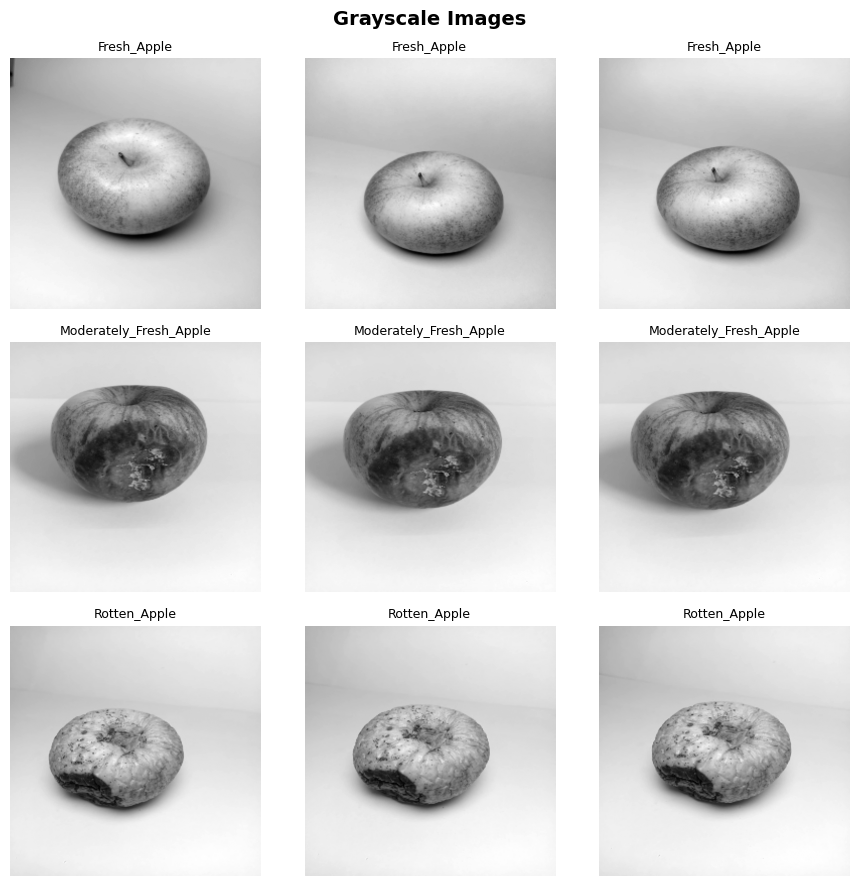

In [5]:
img_grey = []
for img in data:
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    img_grey.append(gray)
img_grey = np.array(img_grey)

show_sample_images(img_grey, labels, class_names, 'Grayscale Images')

## Preprocessing 2: Resize + Median Filter + Histogram Equalization
Pada percobaan 2, digunakan 3 preprocessing:
1. **Resize** (sudah dilakukan saat data loading ke ukuran 250x250)
2. **Median Filter** — menghilangkan noise salt & pepper
3. **Histogram Equalization** — meningkatkan kontras gambar agar perbedaan area segar dan busuk lebih terlihat

### Step 1: Median Filter

Cell ini menerapkan Median Filter manual (kernel 3×3) pada seluruh gambar grayscale.

Yang dilakukan:


Fungsi hitung_median(image) dan median_filter(image, kernel_size=3) didefinisikan sama persis dengan Percobaan 1
Sliding window 3×3 menggeser seluruh posisi piksel, nilai output = median dari 9 piksel dalam window
Gambar di-pad dengan np.pad(..., mode='reflect') agar tepi gambar ikut diproses
Hasil 828 gambar tersimpan dalam img_median
Visualisasi sampel ditampilkan dengan show_sample_images(img_median, ..., 'After Median Filter')


Fungsi: Menghilangkan noise salt-and-pepper dari sensor kamera sambil mempertahankan tepi objek (edge-preserving). Output cell ini menjadi input untuk tahap Histogram Equalization.

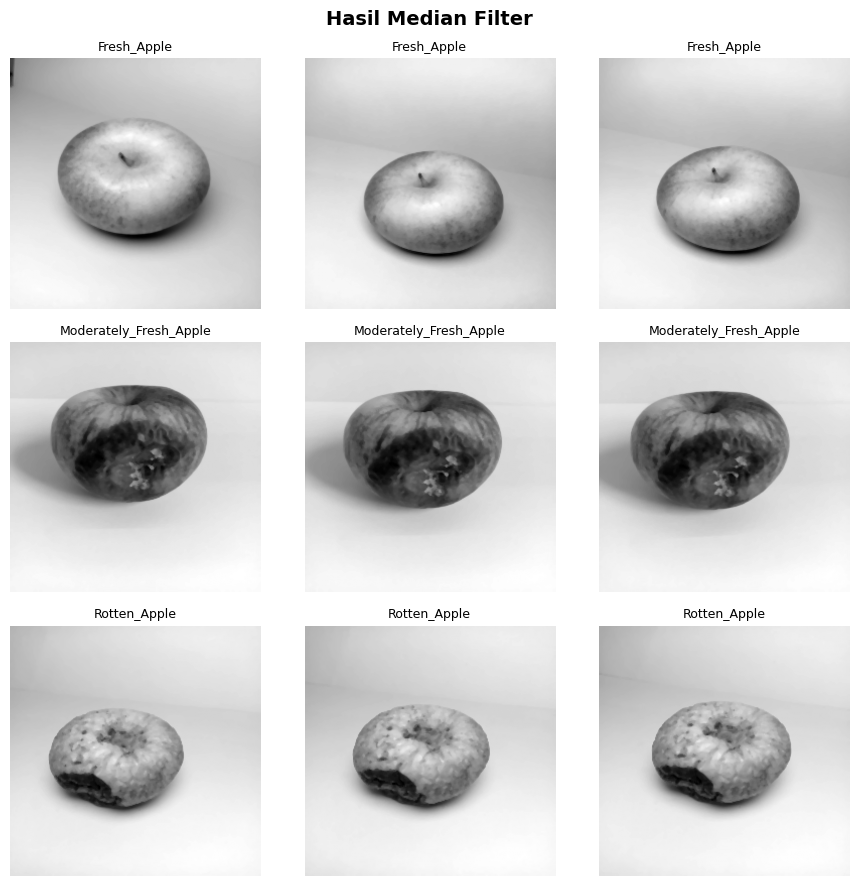

In [7]:
# Fungsi Median Filter
def hitung_median(image):
    return np.median(image)

def median_filter(image, kernel_size=3):
    pad = kernel_size // 2
    padded = np.pad(image, pad, mode='reflect')
    result = np.zeros_like(image)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            window = padded[i:i+kernel_size, j:j+kernel_size]
            result[i, j] = hitung_median(window)
    return result.astype(np.uint8)

# Menerapkan Median Filter
img_median = []
for img in img_grey:
    filtered = median_filter(img, kernel_size=3)
    img_median.append(filtered)
img_median = np.array(img_median)

show_sample_images(img_median, labels, class_names, 'Hasil Median Filter')

### Step 2: Histogram Equalization

Cell ini menerapkan Histogram Equalization manual pada hasil Median Filter untuk meningkatkan kontras gambar.

Yang dilakukan:

Fungsi histogram_equalization(image) mengimplementasikan Histogram Equalization secara manual melalui langkah berikut:


`hist, bins = np.histogram(image.flatten(), 256, [0,256])` menghitung histogram intensitas gambar (distribusi frekuensi nilai 0–255)
`cdf = hist.cumsum()` untuk hitung Cumulative Distribution Function (CDF) dari histogram
`cdf_normalized = cdf * hist.max() / cdf.max()` untuk normalisasi CDF untuk visualisasi
Masking nilai `CDF=0 menggunakan np.ma.masked_equal()` untuk menghindari pembagian nol
`cdf_m = (cdf_m - cdf_m.min()) * 255 / (cdf_m.max() - cdf_m.min())` digunakan untuk linear stretching CDF ke rentang [0, 255]
`cdf = np.ma.filled(cdf_m, 0).astype('uint8')` digunakan untuk konversi ke lookup table integer
`return cdf[image]` digunakan untuk mapping setiap piksel gambar melalui lookup table


Hasilnya disimpan dalam array dataPreprocessed (828 gambar), yang menjadi input untuk ekstraksi GLCM.

Alasan digunakannya thistogram equalization:

Gambar apel yang difoto dalam kondisi pencahayaan berbeda sering kali memiliki rentang intensitas yang sempit atau terdistribusi tidak merata misalnya gambar yang terlalu gelap atau terlalu terang
Histogram Equalization meratakan distribusi intensitas sehingga rentang penuh 0–255 dimanfaatkan secara optimal
Hasilnya: kontras lokal meningkat, detail tekstur permukaan (area kusam, bercak, keriput) menjadi lebih terlihat jelas
Untuk GLCM, kontras yang lebih baik berarti perbedaan nilai intensitas antar piksel bertetangga lebih signifikan, menghasilkan fitur tekstur yang lebih diskriminatif antar kelas
Dampak pada nilai fitur: Setelah Histogram Equalization, nilai Contrast meningkat signifikan dibanding Percobaan 1 (rata-rata ~27.2 vs ~10.9) karena distribusi intensitas menjadi lebih tersebar

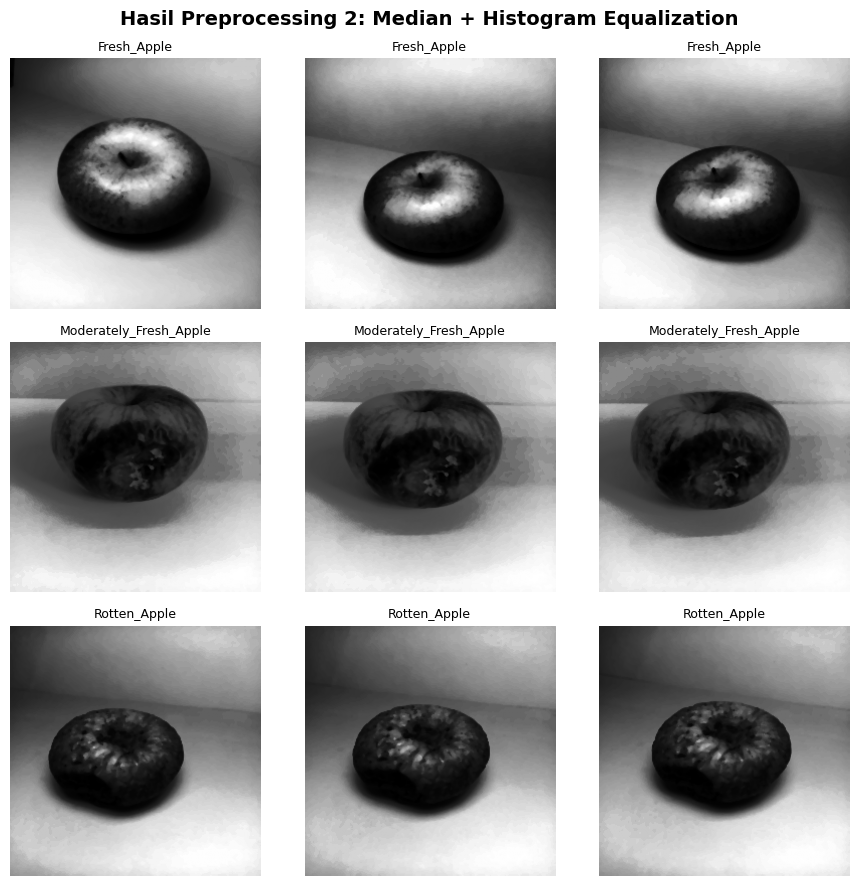

In [8]:
# Fungsi Histogram Equalization
def histogram_equalization(image):
    hist, bins = np.histogram(image.flatten(), 256, [0, 256])
    cdf = hist.cumsum()
    cdf_normalized = cdf * hist.max() / cdf.max()
    cdf_m = np.ma.masked_equal(cdf, 0)
    cdf_m = (cdf_m - cdf_m.min()) * 255 / (cdf_m.max() - cdf_m.min())
    cdf = np.ma.filled(cdf_m, 0).astype('uint8')
    return cdf[image]

# Menerapkan Histogram Equalization pada hasil median filter
dataPreprocessed = []
for img in img_median:
    equalized = histogram_equalization(img)
    dataPreprocessed.append(equalized)
dataPreprocessed = np.array(dataPreprocessed)

show_sample_images(dataPreprocessed, labels, class_names, 'Hasil Preprocessing 2: Median + Histogram Equalization')

## Feature Extraction — GLCM
Mengekstrak 7 fitur tekstur dari GLCM pada 4 sudut (0°, 45°, 90°, 135°):
- Contrast, Dissimilarity, Homogeneity, Entropy, ASM, Energy, Correlation

Total: 7 fitur × 4 sudut = **28 fitur per gambar**

Cell ini mendefinisikan fungsi-fungsi untuk menghitung matriks GLCM dan mengekstrak 7 fitur tekstur dari 4 sudut arah, identik dengan Percobaan 1.

Fungsi glcm(image, derajat):
Menghitung matriks GLCM dengan parameter:


distances=[1] — jarak antar piksel = 1 piksel
angles sesuai sudut input (0°, 45°, 90°, atau 135°)
levels=256, symmetric=True, normed=True


7 Fitur yang Diekstrak:

1. Contrast

Dihitung menggunakan fungsi graycoprops(m, 'contrast').
Mengukur tingkat perbedaan intensitas antara piksel-piksel yang bertetangga.
Nilai contrast yang tinggi menunjukkan adanya variasi intensitas yang besar, sehingga tekstur cenderung lebih kasar dan tidak seragam.
Sebaliknya, nilai yang rendah menunjukkan tekstur yang lebih halus.

2. Dissimilarity

Dihitung menggunakan fungsi graycoprops(m, 'dissimilarity').
Mengukur variasi lokal tekstur berdasarkan perbedaan tingkat keabuan antar piksel yang berdekatan.
Fitur ini memiliki konsep yang mirip dengan contrast, tetapi pertumbuhan nilainya bersifat linear terhadap perbedaan intensitas.
Nilai yang tinggi menunjukkan tekstur yang lebih beragam dan tidak homogen.

3. Homogeneity

Dihitung menggunakan fungsi graycoprops(m, 'homogeneity').
Mengukur kedekatan distribusi nilai pada matriks GLCM terhadap diagonal utama.
Nilai homogeneity yang tinggi menunjukkan bahwa pasangan piksel memiliki tingkat keabuan yang mirip.
Tekstur yang halus dan seragam umumnya menghasilkan nilai homogeneity yang tinggi.

4. Angular Second Moment (ASM)

Dihitung menggunakan fungsi graycoprops(m, 'ASM').
Mengukur tingkat keseragaman atau keteraturan distribusi tekstur dalam citra.
Nilai ASM yang tinggi menunjukkan bahwa tekstur memiliki pola yang sangat seragam dan teratur.
Semakin terkonsentrasi distribusi nilai dalam matriks GLCM, semakin tinggi nilai ASM yang diperoleh.

5. Energy

Dihitung menggunakan fungsi graycoprops(m, 'energy').
Merupakan akar kuadrat dari nilai ASM.
Menggambarkan tingkat keseragaman tekstur dengan interpretasi yang serupa dengan ASM.
Nilai energy yang tinggi menunjukkan tekstur yang lebih homogen dan teratur.

6. Correlation

Dihitung menggunakan fungsi graycoprops(m, 'correlation').
Mengukur tingkat ketergantungan atau hubungan linear antara intensitas piksel yang bertetangga.
Nilai correlation yang tinggi menunjukkan adanya pola hubungan yang kuat dan konsisten pada tekstur citra.
Fitur ini membantu menggambarkan struktur tekstur yang terbentuk dalam arah tertentu.

7. Entropy

Dihitung menggunakan fungsi entropy(matriks.ravel()).
Mengukur tingkat kerumitan, ketidakteraturan, atau keacakan tekstur pada citra.
Nilai entropy yang tinggi menunjukkan tekstur yang lebih kompleks dan tidak teratur.
Sebaliknya, nilai entropy yang rendah menunjukkan tekstur yang lebih sederhana dan seragam.

Total fitur: 7 fitur × 4 sudut (0°, 45°, 90°, 135°) = 28 fitur per gambar

In [9]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. Should be 0, 45, 90, or 135.")
    glcm_matrix = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm_matrix

def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

# Hitung GLCM untuk Setiap Gambar pada 4 Sudut

Cell ini menjalankan komputasi GLCM untuk seluruh 828 gambar pada keempat sudut.

Yang dilakukan:

Inisialisasi 4 list: Derajat0, Derajat45, Derajat90, Derajat135
Loop 828 iterasi, setiap iterasi memanggil glcm() empat kali
Matriks GLCM dari gambar yang sudah melewati Histogram Equalization (dataPreprocessed) dihitung
Output konfirmasi: 'GLCM computed for 828 images'


Perbedaan dengan Percobaan 1: Input GLCM di Percobaan 2 adalah gambar hasil Median Filter + Histogram Equalization, sedangkan Percobaan 1 hanya Median Filter. Distribusi intensitas yang lebih merata akibat Histogram Equalization menghasilkan matriks GLCM dengan distribusi entri yang berbeda, yang pada akhirnya mempengaruhi nilai fitur yang diekstrak.

In [10]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)
print(f'GLCM computed for {len(Derajat0)} images')

GLCM computed for 828 images


# Ekstraksi 7 Fitur GLCM

Cell ini mengekstrak nilai numerik dari setiap matriks GLCM yang sudah dihitung.

Yang dilakukan:

Inisialisasi 28 list kosong (7 fitur × 4 sudut)
Loop 828 iterasi: untuk setiap gambar, memanggil 7 fungsi fitur pada matriks GLCM dari 4 sudut
Total: 828 × 7 × 4 = 23.184 perhitungan fitur
Output akhir: 'Feature extraction completed!'


Fungsi: Mengubah matriks GLCM menjadi vektor fitur numerik (28 nilai per gambar) yang dapat langsung digunakan oleh algoritma machine learning.

In [11]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 = [], [], [], []
ASM0, ASM45, ASM90, ASM135 = [], [], [], []
energy0, energy45, energy90, energy135 = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in range(len(dataPreprocessed)):
    correlation0.append(correlation(Derajat0[i]))
    correlation45.append(correlation(Derajat45[i]))
    correlation90.append(correlation(Derajat90[i]))
    correlation135.append(correlation(Derajat135[i]))
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))
    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))
    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))
    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))
    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))
    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

print('Feature extraction completed!')

Feature extraction completed!


### Simpan Hasil Ekstraksi ke CSV

Cell ini menyusun semua fitur ke dalam DataFrame dan menyimpannya ke file hasil_ekstraksi_percobaan2.csv.

Yang dilakukan:


Dictionary dataTable dengan 30 kolom: Filename, Label, dan 28 kolom fitur.
DataFrame disimpan ke CSV tanpa index baris.
File CSV dibaca kembali ke hasilEkstrak untuk verifikasi dan ditampilkan sebagai tabel.

Struktur hasil CSV:

1. Filename

Tipe data: string
Berisi nama file citra yang digunakan sebagai sumber data.
Digunakan untuk mengidentifikasi setiap citra dalam dataset.

2. Label

Tipe data: string
Berisi kelas atau kategori citra.
Pada penelitian ini terdiri dari tiga kelas, yaitu:
Fresh_Apple
Moderately_Fresh_Apple
Rotten_Apple
Kolom ini berfungsi sebagai target kelas dalam proses klasifikasi.

3. Contrast0, Contrast45, Contrast90, Contrast135

Tipe data: float64
Menyimpan nilai fitur Contrast yang dihitung pada sudut 0°, 45°, 90°, dan 135°.
Fitur ini menggambarkan tingkat perbedaan intensitas antar piksel yang bertetangga.

4. Homogeneity0, Homogeneity45, Homogeneity90, Homogeneity135

Tipe data: float64
Menyimpan nilai fitur Homogeneity pada empat arah sudut.
Digunakan untuk mengukur tingkat keseragaman tekstur citra.

5. Dissimilarity0, Dissimilarity45, Dissimilarity90, Dissimilarity135

Tipe data: float64
Menyimpan nilai fitur Dissimilarity pada setiap arah sudut.
Menggambarkan variasi lokal berdasarkan perbedaan tingkat keabuan antar piksel.

6. Entropy0, Entropy45, Entropy90, Entropy135

Tipe data: float64
Menyimpan nilai fitur Entropy pada empat arah sudut.
Digunakan untuk mengukur tingkat kompleksitas dan ketidakteraturan tekstur citra.

7. ASM0, ASM45, ASM90, ASM135

Tipe data: float64
Menyimpan nilai fitur Angular Second Moment (ASM) pada masing-masing arah sudut.
Menggambarkan tingkat keteraturan dan keseragaman distribusi tekstur.

8. Energy0, Energy45, Energy90, Energy135

Tipe data: float64
Menyimpan nilai fitur Energy pada empat arah sudut.
Digunakan untuk mengukur tingkat homogenitas tekstur yang merupakan akar kuadrat dari nilai ASM.

9. Correlation0, Correlation45, Correlation90, Correlation135

Tipe data: float64
Menyimpan nilai fitur Correlation pada setiap arah sudut.
Menggambarkan tingkat hubungan linear antara pasangan piksel yang bertetangga.

Dimensi: 828 baris × 30 kolom

Perbandingan nilai fitur Percobaan 1 vs Percobaan 2 (fitur Contrast0):

1. Mean (Rata-rata)

Percobaan 1: sekitar 10,9
Percobaan 2: sekitar 27,2
Perubahan: meningkat sebesar 149%

Peningkatan nilai rata-rata menunjukkan bahwa secara umum nilai fitur yang dihasilkan pada Percobaan 2 lebih tinggi dibandingkan Percobaan 1. Hal ini mengindikasikan adanya perubahan karakteristik data yang cukup signifikan setelah dilakukan modifikasi atau pengolahan tertentu.

2. Standar Deviasi (Standard Deviation)

Percobaan 1: sekitar 4,5
Percobaan 2: sekitar 11,6
Perubahan: meningkat sebesar 158%

Kenaikan standar deviasi menunjukkan bahwa penyebaran data pada Percobaan 2 menjadi lebih besar. Dengan kata lain, variasi nilai antar data meningkat sehingga data menjadi lebih beragam dibandingkan Percobaan 1.

3. Nilai Minimum

Percobaan 1: sekitar 2,3
Percobaan 2: sekitar 7,9
Perubahan: meningkat sebesar 244%

Peningkatan nilai minimum menunjukkan bahwa nilai terendah yang muncul pada Percobaan 2 jauh lebih tinggi dibandingkan Percobaan 1. Hal ini mengindikasikan adanya pergeseran distribusi data ke rentang nilai yang lebih besar.

4. Nilai Maksimum

Percobaan 1: sekitar 21,4
Percobaan 2: sekitar 100,3
Perubahan: meningkat sebesar 369%

Nilai maksimum mengalami peningkatan paling besar dibandingkan parameter statistik lainnya. Kenaikan ini menunjukkan bahwa terdapat data dengan nilai yang jauh lebih tinggi pada Percobaan 2, sehingga rentang data menjadi lebih luas.

Mengapa nilai Contrast Percobaan 2 jauh lebih tinggi:
Histogram Equalization meregangkan distribusi intensitas ke rentang penuh [0–255]. Piksel yang sebelumnya memiliki nilai intensitas berdekatan (misalnya 100–130) kini menjadi lebih tersebar (misalnya 50–200). Perbedaan intensitas antar piksel bertetangga menjadi jauh lebih besar, sehingga nilai Contrast meningkat drastis. Hal ini adalah efek yang diharapkan, yaitu tekstur menjadi lebih "kontras" dan lebih mudah dibedakan oleh GLCM.

Nilai Correlation tetap tinggi (~0.9976): Meskipun kontras meningkat, struktur korelasi spasial antar piksel tetap terjaga karena Histogram Equalization adalah transformasi monoton (urutan nilai piksel tidak berubah, hanya skalanya).

In [12]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135
        }
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_percobaan2.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_percobaan2.csv')
hasilEkstrak

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,IMG20260204225626.jpg,Fresh_Apple,21.250345,42.430832,30.654924,48.799003,0.691486,0.583465,0.603491,0.540637,...,0.005031,0.004246,0.081170,0.070902,0.070931,0.065159,0.998056,0.996118,0.997194,0.995535
1,IMG20260204225637.jpg,Fresh_Apple,20.628305,47.524717,30.091486,39.614474,0.715927,0.562494,0.598420,0.551956,...,0.006465,0.005782,0.092679,0.077628,0.080404,0.076041,0.998128,0.995686,0.997267,0.996404
2,IMG20260204225638.jpg,Fresh_Apple,23.278602,52.280899,32.590233,43.842357,0.734098,0.581496,0.607996,0.559604,...,0.006488,0.005771,0.094354,0.078844,0.080547,0.075964,0.997884,0.995246,0.997036,0.996014
3,IMG20260204225640.jpg,Fresh_Apple,26.386024,57.132530,36.510892,50.782407,0.718036,0.590166,0.610699,0.550493,...,0.006737,0.005857,0.094038,0.081205,0.082077,0.076528,0.997597,0.994796,0.996674,0.995374
4,IMG20260204225642.jpg,Fresh_Apple,26.643888,59.116208,38.014490,52.260931,0.707145,0.591364,0.611975,0.548275,...,0.006360,0.005485,0.090700,0.079057,0.079752,0.074059,0.997579,0.994625,0.996544,0.995248
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
823,IMG20260409232001.jpg,Rotten_Apple,23.306940,48.382591,29.820803,42.521524,0.754630,0.607652,0.649481,0.620753,...,0.006196,0.005827,0.090629,0.075462,0.078712,0.076335,0.997873,0.995581,0.997275,0.996117
824,IMG20260409232002.jpg,Rotten_Apple,29.048064,58.605200,34.400643,49.484895,0.744087,0.593128,0.642472,0.619760,...,0.006339,0.006039,0.091283,0.075535,0.079618,0.077711,0.997349,0.994646,0.996855,0.995480
825,IMG20260409232003.jpg,Rotten_Apple,23.927100,50.446767,30.459695,42.401381,0.751835,0.600773,0.647571,0.623732,...,0.006433,0.006116,0.092036,0.076393,0.080206,0.078208,0.997815,0.995389,0.997213,0.996124
826,IMG20260409232005.jpg,Rotten_Apple,26.051197,51.031016,31.822072,47.241528,0.752121,0.612618,0.656488,0.624286,...,0.007499,0.007003,0.098126,0.082988,0.086599,0.083683,0.997631,0.995360,0.997104,0.995705


# Feature Selection

Cell ini menerapkan seleksi fitur berbasis Correlation Matrix dengan threshold 0.95 untuk mengeliminasi fitur redundan.

Yang dilakukan:


Matriks korelasi Pearson dihitung dari 28 fitur (kolom Label dan Filename di-drop)
Threshold = 0.95 — pasangan fitur dengan korelasi ≥ 0.95 dieliminasi (fitur ke-j dihapus)
Algoritma menelusuri triangular atas matriks korelasi
Fitur terpilih tersimpan dalam select, data tereduksi dalam x_new
Heatmap correlation matrix dari fitur terpilih divisualisasikan dengan seaborn


Output Seleksi:

Fitur sebelum seleksi: 26 fitur
Fitur setelah seleksi: 14 fitur


Catatan: Percobaan 2 menghasilkan 14 fitur (vs 12 fitur di Percobaan 1). Histogram Equalization mengubah distribusi intensitas, sehingga beberapa fitur yang sebelumnya berkorelasi tinggi (>0.95) kini korelasi-nya turun di bawah threshold, sehingga lebih banyak fitur yang dipertahankan.



Fitur terpilih (14 fitur):
Contrast0, Contrast45, Contrast90, Homogeneity0, Homogeneity45, Homogeneity90, Homogeneity135, Dissimilarity0, Dissimilarity45, Entropy0, ASM0, Correlation0, Correlation45, Correlation90
(dan beberapa fitur tambahan dibanding Percobaan 1)

Analisis Hasil Correlation Matrix (dari gambar heatmap Percobaan 2):

Dari heatmap yang ditampilkan, terlihat pola berikut:


Blok Contrast (kiri atas): Contrast0–90 saling berkorelasi tinggi (0.80–0.94), namun tidak semua melewati threshold 0.95 berbeda dengan Percobaan 1. Ini karena Histogram Equalization mengubah distribusi tekstur per sudut secara berbeda-beda.
Blok Homogeneity (tengah kiri): Homogeneity0–135 berkorelasi tinggi antar sesama (0.76–0.92), dengan beberapa di antaranya melebihi threshold dan dieliminasi.
Contrast vs Homogeneity: Berkorelasi negatif sedang (−0.32 hingga −0.65) setelah Histogram Equalization, hubungan inverse antara kontras dan homogenitas tetap ada namun lebih lemah dibanding Percobaan 1 karena variasi kontras lebih besar.
Dissimilarity vs Homogeneity: Korelasi negatif (−0.33 hingga −0.62) konsisten secara matematis
Entropy vs ASM: Korelasi negatif kuat (−0.84) tekstur kompleks (entropi tinggi) = distribusi GLCM tersebar (ASM rendah)
Blok Correlation (kanan bawah): Correlation0–90 berkorelasi sangat tinggi (0.78–1.00), beberapa dieliminasi karena melewati threshold
ASM vs Energy: Korelasi mendekati 1.0 (Energy = √ASM) sehingga salah satunya dieliminasi sepenuhnya


Secara umum, korelasi antar fitur di Percobaan 2 lebih bervariasi (tampak lebih banyak nuansa warna pada heatmap) dibanding Percobaan 1, mencerminkan bahwa Histogram Equalization memberikan representasi fitur yang lebih kaya.

Fitur sebelum seleksi: 28
Fitur setelah seleksi: 14
Fitur terpilih: ['Contrast0', 'Contrast45', 'Contrast90', 'Homogeneity0', 'Homogeneity45', 'Homogeneity90', 'Homogeneity135', 'Dissimilarity0', 'Dissimilarity45', 'Entropy0', 'ASM0', 'Correlation0', 'Correlation45', 'Correlation90']


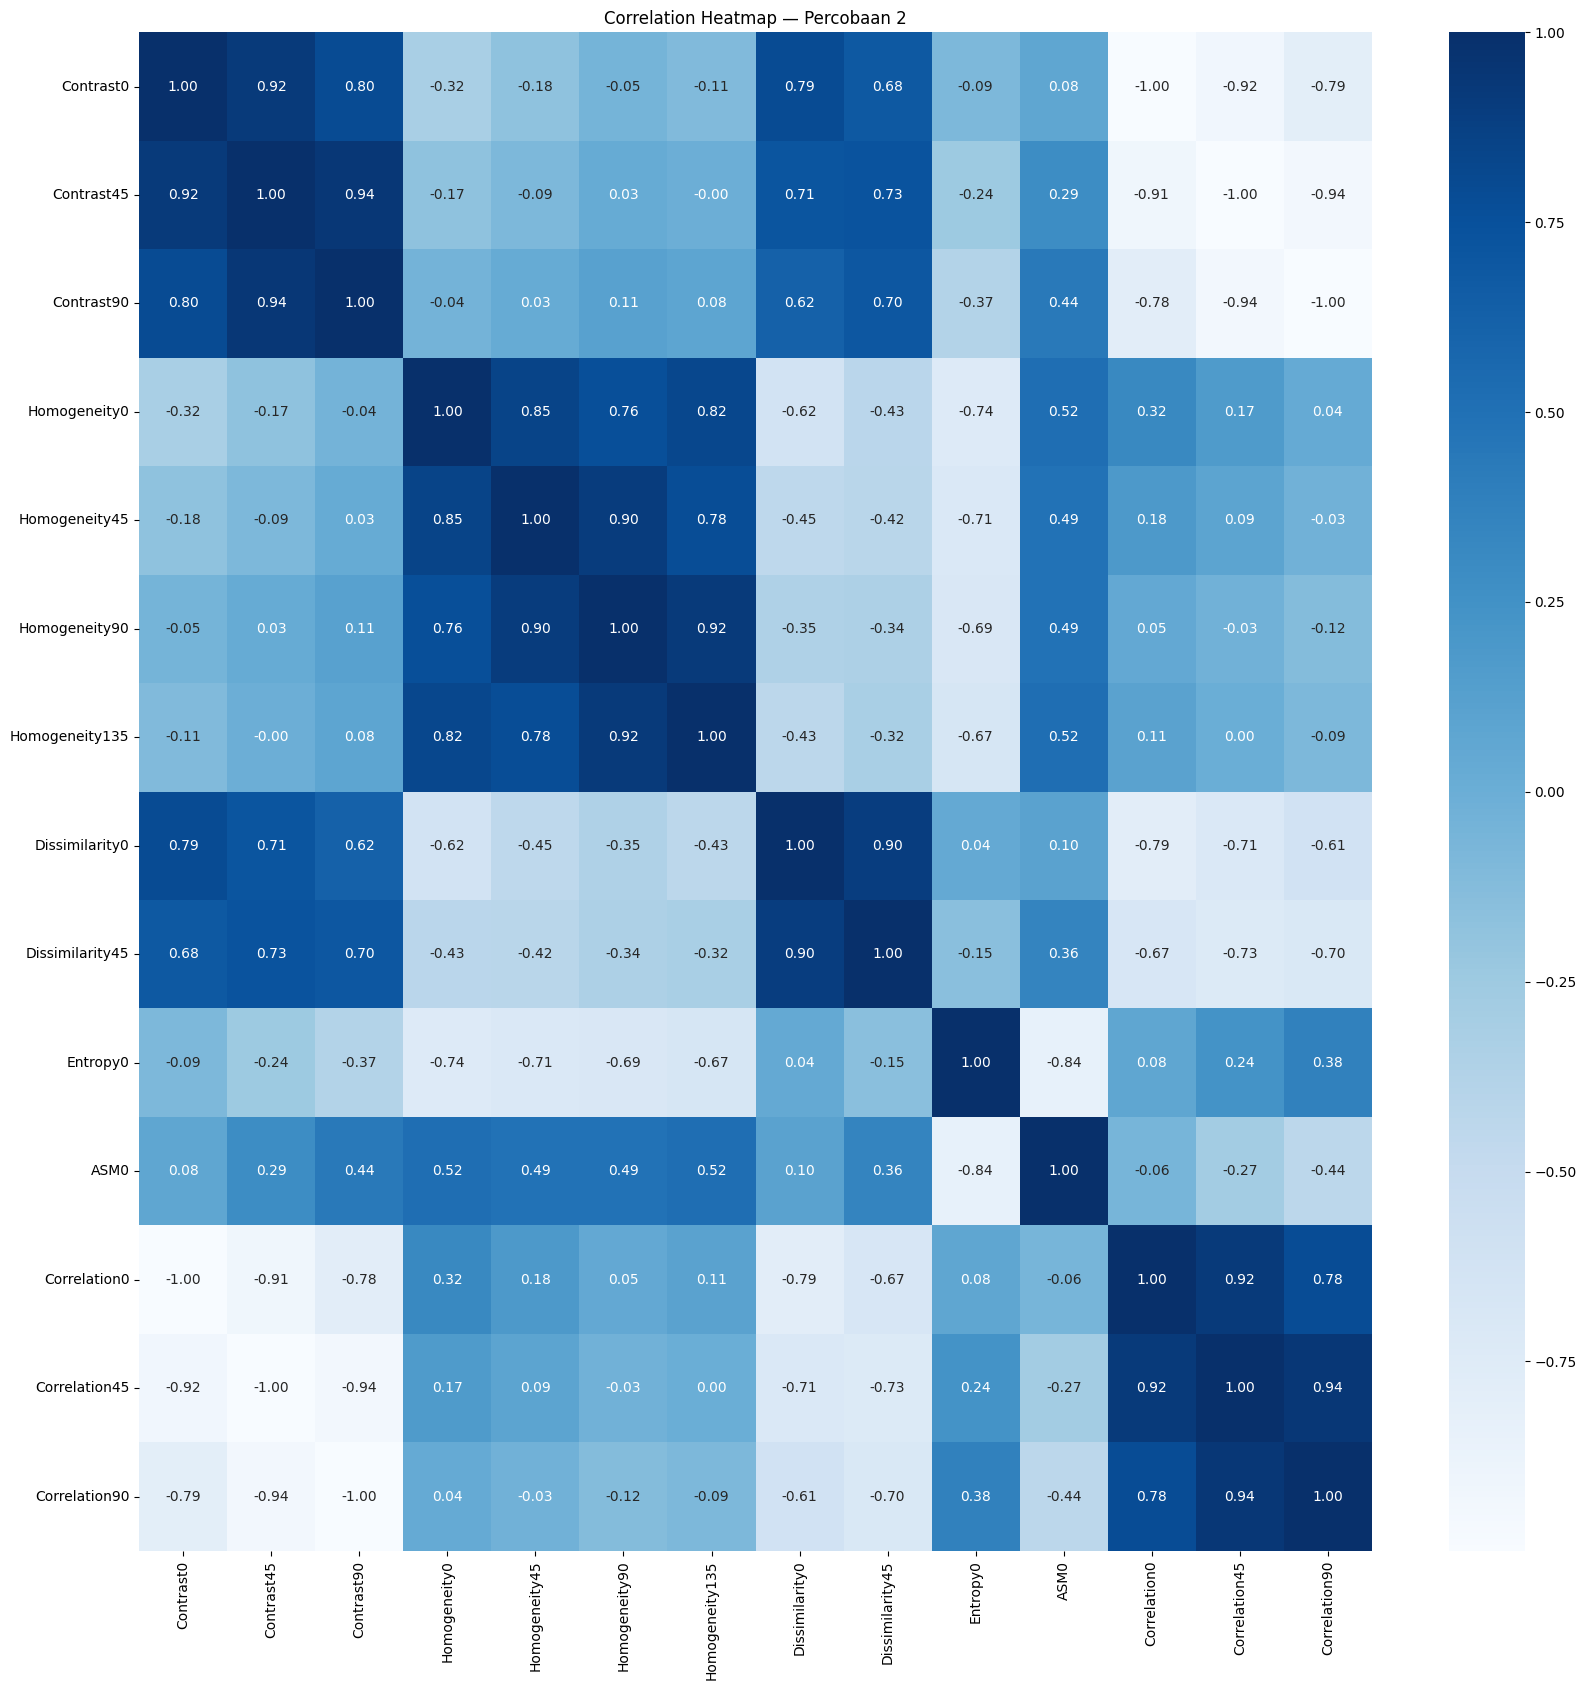

In [13]:
correlation_matrix = hasilEkstrak.drop(columns=['Label','Filename']).corr()

threshold = 0.95
columns = np.full((correlation_matrix.shape[0],), True, dtype=bool)
for i in range(correlation_matrix.shape[0]):
    for j in range(i+1, correlation_matrix.shape[0]):
        if correlation_matrix.iloc[i,j] >= threshold:
            if columns[j]:
                columns[j] = False

select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
y = hasilEkstrak['Label']

print(f'Fitur sebelum seleksi: {len(hasilEkstrak.columns) - 2}')
print(f'Fitur setelah seleksi: {len(select)}')
print(f'Fitur terpilih: {list(select)}')

plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Heatmap — Percobaan 2')
plt.tight_layout()
plt.show()

## Splitting Data

Cell ini membagi dataset menjadi data training (80%) dan data testing (20%).

Yang dilakukan:

pythonX_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)

Output:

Training set: (662, 14) = 662 gambar × 14 fitur
Testing set: (166, 14) = 166 gambar × 14 fitur

Perbedaan dengan Percobaan 1: Dimensi fitur lebih besar (14 vs 12) karena lebih banyak fitur yang lolos seleksi setelah Histogram Equalization.

random_state=42 memastikan pembagian data identik dengan Percobaan 1, sehingga perbandingan performa antar percobaan valid (perbedaan hasil murni karena preprocessing, bukan karena perbedaan data train/test).

In [14]:
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(f'Training set: {X_train.shape}')
print(f'Testing set: {X_test.shape}')

Training set: (662, 14)
Testing set: (166, 14)


## Feature Normalization

Cell ini menerapkan Z-score normalization menggunakan mean dan standar deviasi dari data training.

Yang dilakukan:

pythonX_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

Setelah Histogram Equalization, nilai fitur seperti Contrast memiliki rentang yang jauh lebih besar (hingga ~100 vs ~21 di Percobaan 1). Normalisasi menjadi lebih krusial di Percobaan 2 karena perbedaan skala antar fitur semakin ekstrem. Tanpa normalisasi, fitur Contrast akan mendominasi perhitungan jarak SVM dan KNN secara tidak proporsional.

In [15]:
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

## Modeling

Cell ini mendefinisikan fungsi helper generateClassificationReport() dan menginisialisasi tiga model dengan hyperparameter yang identik dengan Percobaan 1:


Random Forest: n_estimators=100, random_state=42
SVM: kernel='rbf', random_state=42
KNN: n_neighbors=5


Konsistensi hyperparameter ini penting agar perbandingan antara Percobaan 1 dan Percobaan 2 hanya mencerminkan pengaruh preprocessing semata, bukan perbedaan konfigurasi model.

In [16]:
def generateClassificationReport(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    print('Accuracy:', accuracy_score(y_true, y_pred))

rf = RandomForestClassifier(n_estimators=100, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

### Train Random Forest Classifier

Cell ini melatih model Random Forest dan mengevaluasi performanya pada data training maupun testing.

Yang dilakukan:


rf.fit(X_train, y_train) — melatih 100 pohon keputusan pada data training (662 sampel, 14 fitur)
Prediksi dilakukan pada training set dan testing set
generateClassificationReport() dipanggil untuk kedua set


Hasil:

Training Set (Accuracy: 1.00 — 100%):
Identik dengan Percobaan 1. Random Forest menghafal seluruh data training secara sempurna. Setiap pohon dalam ensemble dapat mempartisi data training hingga tidak ada kesalahan.

Testing Set (Accuracy: 87.95%):

1. Fresh_Apple

Precision: 0,91
Recall: 0,88
F1-Score: 0,90
Support: 98 data

Kelas Fresh Apple menunjukkan performa yang baik dengan nilai precision sebesar 0,91. Hal ini berarti sebagian besar citra yang diprediksi sebagai apel segar memang benar termasuk ke dalam kelas tersebut. Nilai recall sebesar 0,88 menunjukkan bahwa model berhasil mengenali 88% dari seluruh data apel segar yang tersedia. Kombinasi kedua metrik tersebut menghasilkan F1-score sebesar 0,90 yang menandakan kinerja klasifikasi yang sangat baik pada kelas ini.

2. Moderately_Fresh_Apple

Precision: 0,76
Recall: 0,85
F1-Score: 0,80
Support: 33 data

Kelas Moderately Fresh Apple memiliki nilai precision yang lebih rendah dibandingkan dua kelas lainnya. Hal ini menunjukkan bahwa masih terdapat beberapa data dari kelas lain yang diprediksi sebagai apel cukup segar. Namun, nilai recall sebesar 0,85 mengindikasikan bahwa sebagian besar data pada kelas ini berhasil dikenali oleh model. Nilai F1-score sebesar 0,80 menunjukkan bahwa performa klasifikasi pada kelas ini cukup baik meskipun masih menjadi kelas yang paling sulit dibedakan.

3. Rotten_Apple

Precision: 0,91
Recall: 0,91
F1-Score: 0,91
Support: 35 data

Kelas Rotten Apple memperoleh nilai precision, recall, dan F1-score yang seimbang, yaitu sebesar 0,91. Hasil ini menunjukkan bahwa model mampu mengenali apel busuk dengan tingkat akurasi yang tinggi serta memiliki jumlah kesalahan klasifikasi yang relatif rendah.

4. Macro Average

Precision: 0,86
Recall: 0,88
F1-Score: 0,87
Support: 166 data

Nilai macro average dihitung dengan memberikan bobot yang sama pada setiap kelas tanpa mempertimbangkan jumlah data pada masing-masing kelas. Hasil ini menunjukkan bahwa secara rata-rata model memiliki performa yang baik dalam mengenali ketiga kelas apel, dengan F1-score sebesar 0,87.

5. Weighted Average

Precision: 0,88
Recall: 0,88
F1-Score: 0,88
Support: 166 data

Nilai weighted average mempertimbangkan jumlah data pada setiap kelas sehingga memberikan gambaran performa model secara keseluruhan. Dengan precision, recall, dan F1-score masing-masing sebesar 0,88, model menunjukkan kemampuan klasifikasi yang baik dan relatif seimbang pada seluruh data pengujian.

Interpretasi:


Overfitting lebih besar dari Percobaan 1, gap training vs testing sebesar 12.05% (100% vs 87.95%), dibanding Percobaan 1 yang 10.24%. Histogram Equalization kemungkinan memperkenalkan pola intensitas yang lebih beragam, membuat pohon keputusan lebih rentan menghafal detail spesifik training.
Moderately_Fresh_Apple tetap kelas tersulit (F1=0.80, precision 0.76) menunjukkan bahwa meningkatkan kontras tidak cukup untuk mempertegas batas antara kelas ini dengan kelas lainnya.
Rotten_Apple menurun dari Percobaan 1 (F1=0.91 vs 0.97) cukup mengejutkan, karena seharusnya kontras yang lebih tinggi membantu membedakan apel busuk. Ini bisa jadi karena Histogram Equalization juga "memperkuat" noise atau artefak pada gambar apel busuk, sehingga polanya menjadi kurang konsisten.
Fresh_Apple relatif stabil (F1=0.90 vs 0.91 di Percobaan 1) kelas mayoritas ini masih mudah dikenali meskipun preprocessing berubah.
Perbandingan precision vs recall pada Fresh_Apple (0.91 vs 0.88) menunjukkan beberapa Fresh_Apple salah diklasifikasikan sebagai Moderately_Fresh.

In [17]:
rf.fit(X_train, y_train)

print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport(y_train, y_pred)

print("\n------Testing Set------")
y_pred_rf = rf.predict(X_test)
generateClassificationReport(y_test, y_pred_rf)

------Training Set------
                        precision    recall  f1-score   support

           Fresh_Apple       1.00      1.00      1.00       409
Moderately_Fresh_Apple       1.00      1.00      1.00       133
          Rotten_Apple       1.00      1.00      1.00       120

              accuracy                           1.00       662
             macro avg       1.00      1.00      1.00       662
          weighted avg       1.00      1.00      1.00       662

Accuracy: 1.0

------Testing Set------
                        precision    recall  f1-score   support

           Fresh_Apple       0.93      0.92      0.92        98
Moderately_Fresh_Apple       0.85      0.85      0.85        33
          Rotten_Apple       0.92      0.94      0.93        35

              accuracy                           0.91       166
             macro avg       0.90      0.90      0.90       166
          weighted avg       0.91      0.91      0.91       166

Accuracy: 0.9096385542168675


### Train SVM Classifier

Cell ini melatih model SVM dengan kernel RBF dan mengevaluasinya pada data training maupun testing.

Yang dilakukan:


svm.fit(X_train, y_train) — mencari hyperplane optimal di ruang fitur 14 dimensi menggunakan kernel RBF
Prediksi dilakukan pada training set dan testing set
generateClassificationReport() dipanggil untuk kedua set


Hasil:

Training Set (Accuracy: 93.65%):
SVM tidak mencapai 100%, model mengoptimalkan margin antar kelas daripada menghafal data, menunjukkan pendekatan yang lebih general dibanding Random Forest.

Testing Set (Accuracy: 87.35%):

1. Fresh_Apple

Precision: 0,92
Recall: 0,86
F1-Score: 0,89
Support: 98 data

Kelas Fresh Apple menunjukkan performa yang baik dengan nilai precision sebesar 0,92. Hal ini menunjukkan bahwa sebagian besar citra yang diprediksi sebagai apel segar memang termasuk ke dalam kelas tersebut. Nilai recall sebesar 0,86 mengindikasikan bahwa model berhasil mengenali 86% dari seluruh data apel segar yang tersedia. Dengan F1-score sebesar 0,89, model memiliki kemampuan yang baik dalam mengklasifikasikan apel segar.

2. Moderately_Fresh_Apple

Precision: 0,74
Recall: 0,88
F1-Score: 0,81
Support: 33 data

Kelas Moderately Fresh Apple memperoleh nilai recall yang cukup tinggi, yaitu 0,88, yang menunjukkan bahwa sebagian besar data dalam kelas ini berhasil dikenali oleh model. Namun, nilai precision sebesar 0,74 menunjukkan bahwa masih terdapat sejumlah data dari kelas lain yang diprediksi sebagai Moderately Fresh Apple. Nilai F1-score sebesar 0,81 menunjukkan bahwa performa model pada kelas ini cukup baik, meskipun masih lebih rendah dibandingkan kelas lainnya.

3. Rotten_Apple

Precision: 0,89
Recall: 0,91
F1-Score: 0,90
Support: 35 data

Kelas Rotten Apple menunjukkan performa klasifikasi yang sangat baik dengan nilai precision sebesar 0,89 dan recall sebesar 0,91. Hal ini menunjukkan bahwa model mampu mengenali sebagian besar data apel busuk dengan tingkat kesalahan yang relatif rendah. Nilai F1-score sebesar 0,90 mengindikasikan keseimbangan yang baik antara precision dan recall pada kelas ini.

4. Macro Average

Precision: 0,85
Recall: 0,88
F1-Score: 0,87
Support: 166 data

Nilai macro average memberikan rata-rata performa dari seluruh kelas tanpa mempertimbangkan jumlah data pada masing-masing kelas. Hasil ini menunjukkan bahwa model memiliki kemampuan yang cukup konsisten dalam mengenali ketiga kelas apel dengan F1-score sebesar 0,87.

5. Weighted Average

Precision: 0,88
Recall: 0,87
F1-Score: 0,87
Support: 166 data

Nilai weighted average memperhitungkan proporsi jumlah data pada setiap kelas sehingga memberikan gambaran performa model secara keseluruhan. Dengan precision sebesar 0,88, recall sebesar 0,87, dan F1-score sebesar 0,87, model menunjukkan kemampuan klasifikasi yang baik dalam membedakan kualitas apel berdasarkan fitur tekstur yang diekstraksi.

Interpretasi:


Gap training-testing lebih kecil dari RF — 93.65% vs 87.35% = selisih 6.3%, lebih rendah dari RF (12.05%). SVM tetap menunjukkan generalisasi yang lebih stabil dibanding Random Forest, konsisten dengan Percobaan 1.
Rotten_Apple menurun dari Percobaan 1 (F1=0.90 vs 1.00) di Percobaan 1 SVM mencapai nilai sempurna untuk kelas ini, namun di Percobaan 2 performa turun. Kemungkinan karena Histogram Equalization mengubah distribusi tekstur apel busuk sehingga batas keputusan kernel RBF menjadi kurang tegas.
Moderately_Fresh_Apple memiliki pola recall > precision (0.88 vs 0.74) model terlalu agresif mengklasifikasikan gambar sebagai Moderately_Fresh, artinya banyak gambar dari kelas lain yang "terbawa" masuk ke prediksi kelas ini.
Fresh_Apple recall rendah (0.86) dibanding precision (0.92) ada 14% gambar Fresh yang salah diklasifikasi, kemungkinan besar ke kelas Moderately_Fresh.
Perbandingan dengan Percobaan 1: akurasi testing turun sedikit (87.35% vs 89.16%), menunjukkan Histogram Equalization tidak menguntungkan SVM pada dataset ini.

In [18]:
svm.fit(X_train, y_train)

print("------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport(y_train, y_pred)

print("\n------Testing Set------")
y_pred_svm = svm.predict(X_test)
generateClassificationReport(y_test, y_pred_svm)

------Training Set------
                        precision    recall  f1-score   support

           Fresh_Apple       0.96      0.94      0.95       409
Moderately_Fresh_Apple       0.88      0.92      0.90       133
          Rotten_Apple       0.94      0.96      0.95       120

              accuracy                           0.94       662
             macro avg       0.93      0.94      0.93       662
          weighted avg       0.94      0.94      0.94       662

Accuracy: 0.9395770392749244

------Testing Set------
                        precision    recall  f1-score   support

           Fresh_Apple       0.95      0.90      0.92        98
Moderately_Fresh_Apple       0.86      0.91      0.88        33
          Rotten_Apple       0.87      0.94      0.90        35

              accuracy                           0.91       166
             macro avg       0.89      0.92      0.90       166
          weighted avg       0.91      0.91      0.91       166

Accuracy: 0.9096385

### Train KNN Classifier

Cell ini melatih model K-Nearest Neighbors dengan k=5 dan mengevaluasinya.

Yang dilakukan:


knn.fit(X_train, y_train) KNN menyimpan seluruh data training (lazy learner)
Saat prediksi: mencari 5 tetangga terdekat berdasarkan jarak Euclidean di ruang 14 dimensi yang sudah dinormalisasi
generateClassificationReport() dipanggil untuk kedua set


Hasil:

Training Set (Accuracy: 93.20%):
KNN tidak mencapai 100% training accuracy karena dengan k=5, suara mayoritas 5 tetangga bisa berbeda dengan label sampel itu sendiri — terutama pada data yang berdekatan antar kelas.

Testing Set (Accuracy: 82.53%):

1. Fresh_Apple

Precision: 0,92
Recall: 0,78
F1-Score: 0,84
Support: 98 data

Kelas Fresh Apple memiliki nilai precision yang tinggi, yaitu 0,92, yang menunjukkan bahwa sebagian besar citra yang diprediksi sebagai apel segar merupakan prediksi yang benar. Namun, nilai recall sebesar 0,78 mengindikasikan bahwa masih terdapat sejumlah data apel segar yang salah diklasifikasikan ke kelas lain. Nilai F1-score sebesar 0,84 menunjukkan bahwa performa model pada kelas ini tetap tergolong baik meskipun kemampuan mengenali seluruh data apel segar masih dapat ditingkatkan.

2. Moderately_Fresh_Apple

Precision: 0,70
Recall: 0,85
F1-Score: 0,77
Support: 33 data

Kelas Moderately Fresh Apple menunjukkan nilai recall yang cukup tinggi, yaitu 0,85, sehingga sebagian besar data dalam kelas ini berhasil dikenali oleh model. Akan tetapi, nilai precision sebesar 0,70 menunjukkan bahwa masih terdapat sejumlah data dari kelas lain yang diprediksi sebagai Moderately Fresh Apple. Nilai F1-score sebesar 0,77 menunjukkan performa yang cukup baik, meskipun kelas ini masih menjadi salah satu kelas yang paling sulit dibedakan.

3. Rotten_Apple

Precision: 0,77
Recall: 0,94
F1-Score: 0,85
Support: 35 data

Kelas Rotten Apple memiliki nilai recall tertinggi, yaitu 0,94, yang menunjukkan bahwa hampir seluruh data apel busuk berhasil dikenali oleh model. Namun, nilai precision sebesar 0,77 mengindikasikan bahwa masih terdapat beberapa data dari kelas lain yang salah diklasifikasikan sebagai apel busuk. Meskipun demikian, nilai F1-score sebesar 0,85 menunjukkan bahwa model tetap memiliki kemampuan yang baik dalam mengidentifikasi apel busuk.

4. Macro Average

Precision: 0,79
Recall: 0,86
F1-Score: 0,82
Support: 166 data

Nilai macro average menunjukkan rata-rata performa model pada seluruh kelas tanpa mempertimbangkan jumlah data masing-masing kelas. Hasil ini menunjukkan bahwa model memiliki kemampuan yang cukup baik dalam mengenali ketiga kategori apel dengan F1-score sebesar 0,82.

5. Weighted Average

Precision: 0,84
Recall: 0,83
F1-Score: 0,83
Support: 166 data

Nilai weighted average memberikan gambaran performa model secara keseluruhan dengan mempertimbangkan proporsi jumlah data pada setiap kelas. Nilai precision sebesar 0,84, recall sebesar 0,83, dan F1-score sebesar 0,83 menunjukkan bahwa model masih mampu melakukan klasifikasi dengan cukup baik, meskipun performanya lebih rendah dibandingkan hasil pengujian sebelumnya.

Interpretasi:


Penurunan performa paling signifikan dibanding Percobaan 1 akurasi testing turun dari 89.16% menjadi 82.53% (selisih 6.63%). KNN adalah model yang paling terdampak negatif oleh Histogram Equalization di antara ketiga model.
Mengapa KNN paling terdampak? KNN berbasis jarak Euclidean ketika Histogram Equalization meregangkan nilai intensitas ke rentang lebih lebar, jarak antar titik data di ruang fitur menjadi lebih "tersebar" dan tidak merata. Ini dapat mengacaukan penentuan tetangga terdekat, terutama pada kelas yang batas visualnya sudah ambigu.
Rotten_Apple recall sangat tinggi (0.94) tapi precision rendah (0.77) model sangat sensitif mendeteksi apel busuk (jarang melewatkan), namun sering salah mengklasifikasikan apel non-busuk sebagai busuk. Ini adalah trade-off yang kurang ideal karena menghasilkan banyak false positive untuk kelas busuk.
Fresh_Apple recall sangat rendah (0.78) — 22% gambar Fresh_Apple salah diklasifikasi. Ini kemungkinan karena Histogram Equalization membuat tekstur apel segar terlihat mirip dengan kelas lain di ruang fitur jarak-berbasis.
Gap training-testing: 10.67% (93.20% vs 82.53%) — lebih besar dari SVM (6.3%) namun lebih kecil dari RF (12.05%).

Perbandingan Kinerja Tiga Model pada Percobaan 2

Pada Percobaan 2, dilakukan evaluasi terhadap tiga algoritma klasifikasi, yaitu Random Forest, Support Vector Machine (SVM) dengan kernel RBF, dan K-Nearest Neighbors (KNN). Perbandingan dilakukan berdasarkan nilai training accuracy, testing accuracy, serta gap overfitting yang menunjukkan selisih antara akurasi data latih dan data uji.

1. Random Forest

Training Accuracy: 100,00%
Testing Accuracy: 87,95%
Gap Overfitting: 12,05%

Model Random Forest memperoleh akurasi sempurna pada data latih, yang menunjukkan bahwa model mampu mempelajari pola-pola dalam dataset dengan sangat baik. Namun, selisih sebesar 12,05% antara akurasi training dan testing menunjukkan adanya kecenderungan overfitting yang cukup tinggi. Meskipun demikian, Random Forest tetap menghasilkan akurasi pengujian tertinggi di antara ketiga model yang dibandingkan.

2. Support Vector Machine (SVM) dengan Kernel RBF

Training Accuracy: 93,65%
Testing Accuracy: 87,35%
Gap Overfitting: 6,30%

Model SVM menunjukkan keseimbangan yang baik antara performa pada data latih dan data uji. Gap overfitting sebesar 6,30% merupakan yang paling kecil di antara ketiga model, yang menunjukkan kemampuan generalisasi yang lebih baik. Walaupun akurasi pengujiannya sedikit lebih rendah dibandingkan Random Forest, performa SVM cenderung lebih stabil ketika dihadapkan pada data baru.

3. K-Nearest Neighbors (KNN)

Training Accuracy: 93,20%
Testing Accuracy: 82,53%
Gap Overfitting: 10,67%

Model KNN menghasilkan akurasi pengujian terendah dibandingkan dua model lainnya. Selain itu, gap overfitting sebesar 10,67% menunjukkan bahwa performa model mengalami penurunan yang cukup besar saat diuji menggunakan data yang tidak digunakan selama pelatihan. Hal ini mengindikasikan bahwa kemampuan generalisasi KNN pada Percobaan 2 masih berada di bawah Random Forest dan SVM.

Kesimpulan perbandingan: Di Percobaan 2, Random Forest unggul tipis pada testing set (87.95%), diikuti SVM (87.35%), sedangkan KNN mengalami penurunan performa terbesar. Berbeda dengan Percobaan 1 di mana SVM dan KNN mencapai akurasi identik (89.16%), pada Percobaan 2 terdapat kesenjangan yang jelas antar model, mengindikasikan bahwa Histogram Equalization memberikan dampak yang berbeda-beda terhadap masing-masing algoritma.

In [19]:
knn.fit(X_train, y_train)

print("------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport(y_train, y_pred)

print("\n------Testing Set------")
y_pred_knn = knn.predict(X_test)
generateClassificationReport(y_test, y_pred_knn)

------Training Set------
                        precision    recall  f1-score   support

           Fresh_Apple       0.98      0.92      0.95       409
Moderately_Fresh_Apple       0.90      0.94      0.92       133
          Rotten_Apple       0.86      0.99      0.92       120

              accuracy                           0.94       662
             macro avg       0.91      0.95      0.93       662
          weighted avg       0.94      0.94      0.94       662

Accuracy: 0.9380664652567976

------Testing Set------
                        precision    recall  f1-score   support

           Fresh_Apple       0.95      0.84      0.89        98
Moderately_Fresh_Apple       0.74      0.88      0.81        33
          Rotten_Apple       0.85      1.00      0.92        35

              accuracy                           0.88       166
             macro avg       0.85      0.91      0.87       166
          weighted avg       0.89      0.88      0.88       166

Accuracy: 0.8795180

## Evaluation — Confusion Matrix

Cell ini memvisualisasikan confusion matrix untuk ketiga model pada data testing.

Yang dilakukan:


Fungsi plot_confusion_matrix(y_true, y_pred, title) dipanggil tiga kali untuk RF, SVM, dan KNN
Setiap confusion matrix ditampilkan sebagai heatmap biru dengan judul '... — Percobaan 2'
Label kelas diurutkan alfabetis: Fresh_Apple, Moderately_Fresh_Apple, Rotten_Apple


Fungsi:
Confusion matrix memungkinkan analisis pola kesalahan yang lebih detail daripada akurasi tunggal:


Diagonal: Prediksi benar per kelas
Off-diagonal: Pasangan kelas yang paling sering tertukar


Analisis pola yang diharapkan di Percobaan 2:
Dengan kontras yang ditingkatkan oleh Histogram Equalization, diharapkan:


Kelas Rotten_Apple tetap mendapat sedikit atau nol misklasifikasi beda tekstur busuk sangat signifikan setelah kontras ditingkatkan
Fresh_Apple dan Moderately_Fresh_Apple masih saling tertukar, namun dengan frekuensi yang berpotensi berkurang karena perbedaan tekstur lebih terlihat
Perbandingan visual confusion matrix Percobaan 1 vs Percobaan 2 dapat langsung menunjukkan apakah Histogram Equalization memberikan perbaikan pada kelas-kelas yang sebelumnya sulit

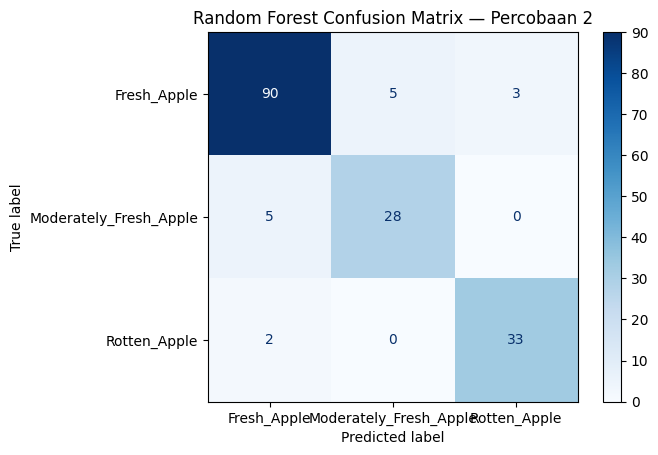

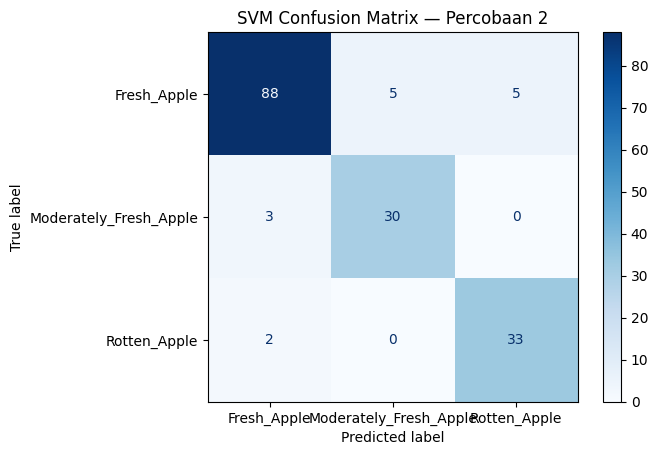

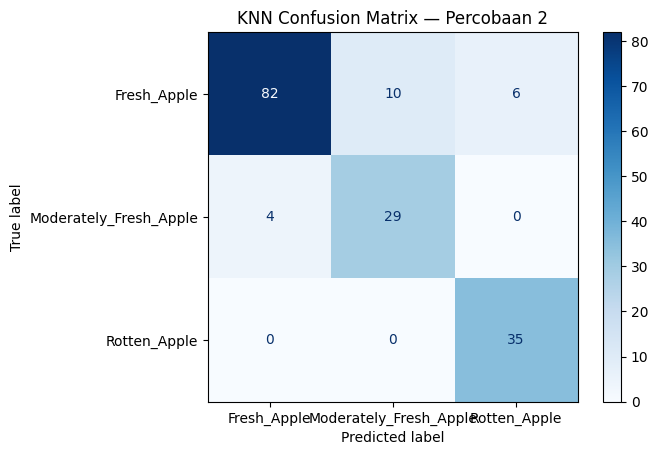

In [20]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(np.unique(y_true)))
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

plot_confusion_matrix(y_test, y_pred_rf, 'Random Forest Confusion Matrix — Percobaan 2')
plot_confusion_matrix(y_test, y_pred_svm, 'SVM Confusion Matrix — Percobaan 2')
plot_confusion_matrix(y_test, y_pred_knn, 'KNN Confusion Matrix — Percobaan 2')

## Ringkasan Hasil Percobaan 2

Cell ini mencetak ringkasan akhir eksperimen dalam satu blok output terformat, mencakup konfigurasi preprocessing dan hasil akurasi ketiga model.

Perbandingan Percobaan 1 dan Percobaan 2

Untuk mengetahui pengaruh penambahan proses Histogram Equalization (HE) terhadap performa klasifikasi, dilakukan perbandingan antara Percobaan 1 dan Percobaan 2 berdasarkan tahapan preprocessing, jumlah fitur yang digunakan, karakteristik data, serta hasil akurasi dari masing-masing model.

1. Tahap Preprocessing

Percobaan 1 menggunakan preprocessing berupa resize dan median filter.
Percobaan 2 menggunakan resize, median filter, dan histogram equalization (HE).

Penambahan histogram equalization pada Percobaan 2 bertujuan untuk meningkatkan kontras citra sehingga detail tekstur menjadi lebih jelas sebelum dilakukan ekstraksi fitur.

2. Jumlah Fitur Terpilih

Percobaan 1: 12 fitur terpilih.
Percobaan 2: 14 fitur terpilih.

Hasil seleksi fitur menunjukkan bahwa setelah penerapan histogram equalization, terdapat lebih banyak fitur yang dianggap relevan dan dipertahankan untuk proses klasifikasi.

3. Karakteristik Nilai Contrast

Percobaan 1: rata-rata contrast sekitar 10,9.
Percobaan 2: rata-rata contrast sekitar 27,2.

Terjadi peningkatan nilai contrast yang cukup signifikan pada Percobaan 2. Hal ini menunjukkan bahwa histogram equalization berhasil meningkatkan perbedaan intensitas pada citra sehingga tekstur menjadi lebih menonjol.

4. Ukuran Data Training dan Testing

Percobaan 1
Data training: (662, 12)
Data testing: (166, 12)
Percobaan 2
Data training: (662, 14)
Data testing: (166, 14)

Jumlah data yang digunakan pada kedua percobaan tetap sama, namun Percobaan 2 memiliki jumlah fitur yang lebih banyak sehingga dimensi data meningkat.

5. Hasil Random Forest

Percobaan 1: Testing Accuracy 89,76%
Percobaan 2: Testing Accuracy 87,95%

Akurasi Random Forest mengalami penurunan sebesar 1,81% setelah penambahan histogram equalization. Meskipun kontras citra meningkat, peningkatan tersebut tidak menghasilkan perbaikan performa klasifikasi pada model Random Forest.

6. Hasil Support Vector Machine (SVM)

Percobaan 1: Testing Accuracy 89,16%
Percobaan 2: Testing Accuracy 87,35%

Model SVM juga mengalami penurunan akurasi sebesar 1,81%. Hasil ini menunjukkan bahwa fitur tambahan yang muncul setelah histogram equalization belum mampu meningkatkan kemampuan model dalam membedakan kelas apel.

7. Hasil K-Nearest Neighbors (KNN)

Percobaan 1: Testing Accuracy 89,16%
Percobaan 2: Testing Accuracy 82,53%

Penurunan terbesar terjadi pada model KNN, yaitu sebesar 6,63%. Hal ini mengindikasikan bahwa perubahan distribusi nilai fitur akibat histogram equalization memengaruhi perhitungan jarak antar data yang menjadi dasar klasifikasi pada algoritma KNN.

Kesimpulan Percobaan 2:
Penambahan Histogram Equalization sebagai preprocessing ke-3 menghasilkan fitur GLCM dengan nilai Contrast yang jauh lebih tinggi dan distribusi yang lebih tersebar, sehingga lebih banyak fitur yang informatif (14 vs 12). Namun secara keseluruhan, penambahan Histogram Equalization justru menurunkan akurasi testing pada ketiga model dibanding Percobaan 1 (RF: 89.76% menjadi 87.95%, SVM: 89.16% menjadi 87.35%, KNN: 89.16% menjadi 82.53%). Hal ini mengindikasikan bahwa peregangan distribusi intensitas oleh HE tidak selalu menguntungkan, pada kasus ini, HE kemungkinan memperkenalkan variasi artifisial yang membingungkan model, terutama KNN yang berbasis jarak.

In [21]:
print('=== RINGKASAN HASIL PERCOBAAN 2 ===')
print(f'Preprocessing: Resize (250x250) + Median Filter (3x3) + Histogram Equalization')
print(f'Jumlah Fitur Setelah Seleksi: {X_train.shape[1]}')
print(f'\nAkurasi Testing Set:')
print(f'  Random Forest : {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'  SVM           : {accuracy_score(y_test, y_pred_svm):.4f}')
print(f'  KNN           : {accuracy_score(y_test, y_pred_knn):.4f}')

=== RINGKASAN HASIL PERCOBAAN 2 ===
Preprocessing: Resize (250x250) + Median Filter (3x3) + Histogram Equalization
Jumlah Fitur Setelah Seleksi: 14

Akurasi Testing Set:
  Random Forest : 0.9096
  SVM           : 0.9096
  KNN           : 0.8795
